<a href="https://colab.research.google.com/github/HJJunn/Art_Therapy_Chat_bot/blob/main/%EC%9E%84%EB%B2%A0%EB%94%A9_%EB%AA%A8%EB%8D%B8_%ED%81%AC%EB%A1%9C%EC%8A%A4_%EC%9D%B8%EC%BD%94%EB%8D%94.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install langchain langchain_openai langchain_community pypdf faiss-cpu

# 문서 청킹

In [4]:
import re
from langchain.schema import Document

# ✅ 1. txt 파일 불러오기
with open("/content/브런치_집-나무-사람 해석 수기본.txt", "r", encoding="utf-8") as f:
    text = f.read()

print("텍스트 로드 완료! 총 길이:", len(text))

# ✅ 2. 카테고리 자동 감지 함수
def detect_category(text):
    if "집" in text:
        return "집"
    elif "나무" in text:
        return "나무"
    elif "사람" in text:
        return "사람"
    else:
        return "기타"

import re
from langchain.schema import Document

# 1. 줄바꿈 제거, 공백 정리
text = re.sub(r'\s+', ' ', text).strip()  # 연속 공백 모두 1칸으로 통일

# 2. 번호 기준으로 청크 나누기
chunks = re.split(r'(?=\n?\d+\.)', text)
chunks = [chunk.strip() for chunk in chunks if chunk.strip()]

# ✅ 4. 각 청크에 카테고리 태깅 + '*' 기준 2차 청킹
langchain_docs = []
for i, chunk in enumerate(chunks):
    # '*', '■' 기호가 있으면 추가로 분리
    if '■' in chunk or '*' in chunk:
        subchunks = re.split(r'(?=[■*])', chunk)
        subchunks = [s.strip() for s in subchunks if s.strip()]
        for j, subchunk in enumerate(subchunks):
            category = detect_category(subchunk)
            langchain_docs.append(
                Document(
                    page_content=subchunk,
                    metadata={
                        "chunk_index": f"{i + 1}-{j + 1}",  # ex: 3-1, 3-2
                        "category": category
                    }
                )
            )
    else:
        category = detect_category(chunk)
        langchain_docs.append(
            Document(
                page_content=chunk,
                metadata={
                    "chunk_index": i + 1,
                    "category": category
                }
            )
        )

# ✅ 5. 결과 확인
print(f"총 {len(langchain_docs)}개 청크 생성 완료\n")
for doc in langchain_docs[:5]:  # 상위 5개만 미리보기
    print(f"[{doc.metadata['category']}] {doc.page_content}")
    print("-" * 60)



텍스트 로드 완료! 총 길이: 52954
총 194개 청크 생성 완료

[기타] ﻿
------------------------------------------------------------
[집] 1. 제목: HTP : 집 집은 일상생활에서의 가정생활, 또는 가족 내에서의 자신에 대한 인식을 나타낸다. 자신의 현실의 모습일 수도 있고, 또는 자신이 바라는 모습, 또는 가족의 생활패턴을 나타낸다. 지붕 지붕의 핵심은 머리로 상상할 수 있는 생각을 나타낸다.
------------------------------------------------------------
[기타] ■ 과도하게 큰 지붕을 그린다 자신만의 환상을 가지고 있다 사회생활을 피하며 자신만의 상상에 몰두한다 지붕이 그림의 전부인 것 마냥 그린다 상상과 공상을 통해 일상생활을 유지한다 학대를 받았을 가능성이 존재한다. 단 이것이 학대를 나타내는 지표로 사용되어서는 안 된다. 현실적으로 통용되지 않는 정신적인 망상을 할 수 있다 망상을 통해 일상생활을 도피하려는 시도일 수 있다
------------------------------------------------------------
[기타] ■ 지붕이 없다 지능 발달이 뒤쳐져 있을 수 있다. 단 이것이 지능 발달의 수준을 판가름 하는 진단기준이 되어서는 안 된다. 자신을 표현하는 방법을 완전히 잃어 버린 경우가 존재한다 단순한 직선, 또는 1차원 적으로 간단히 지붕을 표현한다 매우 경직되어 있다 남에게 잘 어울리지 못 한다
------------------------------------------------------------
[기타] ■ 여러 번 덧칠하거나 진하게 칠함으로써 지붕을 강조한다 환상적인 상상을 통해 현실을 도피하려는 시도이다 정신적으로 어려워지기 시작하는 경우 빈번히 나타나는 징조 중 하나이다. 단 이것이 정신적인 어려움을 나타내는 지표로 사용되어서는 안 된다. 지붕의 꼭대기가 열려 있다 현실과 자신의 생각을 구별하기 어려워 

## 2. 카테고리 수정

In [5]:
# 카테고리가 잘 들어갔는지 확인
for i, doc in enumerate(langchain_docs, start=1):
    print(f"{i}: {doc.metadata.get('category', '없음')}")

1: 기타
2: 집
3: 기타
4: 기타
5: 기타
6: 사람
7: 사람
8: 사람
9: 사람
10: 기타
11: 집
12: 기타
13: 사람
14: 기타
15: 집
16: 집
17: 집
18: 집
19: 기타
20: 집
21: 기타
22: 사람
23: 기타
24: 기타
25: 사람
26: 기타
27: 기타
28: 집
29: 기타
30: 집
31: 기타
32: 기타
33: 기타
34: 집
35: 집
36: 집
37: 집
38: 집
39: 집
40: 집
41: 기타
42: 집
43: 집
44: 집
45: 집
46: 집
47: 기타
48: 사람
49: 집
50: 집
51: 나무
52: 나무
53: 나무
54: 나무
55: 나무
56: 나무
57: 나무
58: 나무
59: 나무
60: 나무
61: 나무
62: 나무
63: 나무
64: 나무
65: 나무
66: 사람
67: 집
68: 기타
69: 집
70: 기타
71: 나무
72: 나무
73: 집
74: 기타
75: 기타
76: 사람
77: 기타
78: 사람
79: 기타
80: 기타
81: 기타
82: 기타
83: 사람
84: 기타
85: 기타
86: 기타
87: 집
88: 사람
89: 사람
90: 기타
91: 기타
92: 사람
93: 나무
94: 기타
95: 사람
96: 사람
97: 사람
98: 기타
99: 나무
100: 나무
101: 나무
102: 사람
103: 사람
104: 집
105: 사람
106: 사람
107: 기타
108: 사람
109: 기타
110: 기타
111: 기타
112: 사람
113: 집
114: 기타
115: 사람
116: 기타
117: 사람
118: 기타
119: 사람
120: 사람
121: 사람
122: 집
123: 기타
124: 기타
125: 기타
126: 기타
127: 기타
128: 사람
129: 사람
130: 기타
131: 집
132: 집
133: 기타
134: 기타
135: 기타
136: 집
137: 집
138: 기타
139: 사람
140: 집
141: 사람
142: 집
143: 기타


In [6]:
langchain_docs[101]

Document(metadata={'chunk_index': '17-1', 'category': '사람'}, page_content='3. 제목: HTP : 사람 사람 그림은 매우 직관적으로 자신의 삶을 드러낸다. 즉, 사람을 그린 그림은 엄청난 정보를 줄 수 있지만 그것을 해석하는 것에 있어서 어려움을 겪게 된다. 그 이유는 주는 정보가 방대하여 해석을 하기에 어려운 부분이 존재하기도 하나, 다양한 표현과 의미가 나타내는 포괄정인 정확한 의도를 깨닫기 난해하기 때문이다.')

In [7]:
# 카테고리 수정
for i, doc in enumerate(langchain_docs, start=1):
    if 0 <= i <= 51:
        doc.metadata['category'] = '집'
    elif 52 <= i <= 101:
        doc.metadata['category'] = '나무'
    elif 102 <= i :
        doc.metadata['category'] = '사람'


In [8]:
# 수정된 카테고리
for i, doc in enumerate(langchain_docs, start=1):
    print(f"{i-1}: {doc.metadata.get('category', '없음')}")

0: 집
1: 집
2: 집
3: 집
4: 집
5: 집
6: 집
7: 집
8: 집
9: 집
10: 집
11: 집
12: 집
13: 집
14: 집
15: 집
16: 집
17: 집
18: 집
19: 집
20: 집
21: 집
22: 집
23: 집
24: 집
25: 집
26: 집
27: 집
28: 집
29: 집
30: 집
31: 집
32: 집
33: 집
34: 집
35: 집
36: 집
37: 집
38: 집
39: 집
40: 집
41: 집
42: 집
43: 집
44: 집
45: 집
46: 집
47: 집
48: 집
49: 집
50: 집
51: 나무
52: 나무
53: 나무
54: 나무
55: 나무
56: 나무
57: 나무
58: 나무
59: 나무
60: 나무
61: 나무
62: 나무
63: 나무
64: 나무
65: 나무
66: 나무
67: 나무
68: 나무
69: 나무
70: 나무
71: 나무
72: 나무
73: 나무
74: 나무
75: 나무
76: 나무
77: 나무
78: 나무
79: 나무
80: 나무
81: 나무
82: 나무
83: 나무
84: 나무
85: 나무
86: 나무
87: 나무
88: 나무
89: 나무
90: 나무
91: 나무
92: 나무
93: 나무
94: 나무
95: 나무
96: 나무
97: 나무
98: 나무
99: 나무
100: 나무
101: 사람
102: 사람
103: 사람
104: 사람
105: 사람
106: 사람
107: 사람
108: 사람
109: 사람
110: 사람
111: 사람
112: 사람
113: 사람
114: 사람
115: 사람
116: 사람
117: 사람
118: 사람
119: 사람
120: 사람
121: 사람
122: 사람
123: 사람
124: 사람
125: 사람
126: 사람
127: 사람
128: 사람
129: 사람
130: 사람
131: 사람
132: 사람
133: 사람
134: 사람
135: 사람
136: 사람
137: 사람
138: 사람
139: 사람
140: 사람
141: 사람
142: 사람
143: 사람
144: 사람
1

## 3. 불필요한 문서 삭제

문서의 최대 길이 : 649
문서의 최소 길이 : 1
문서의 평균 길이 : 264.659793814433


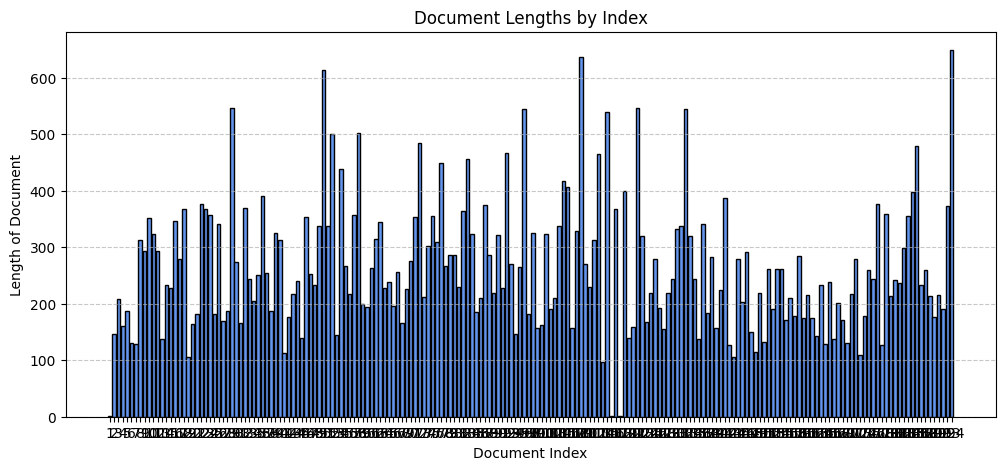

In [9]:
import matplotlib.pyplot as plt

# 각 문서 길이 계산 (문자 수 기준)
doc_lengths = [len(doc.page_content) for doc in langchain_docs]

# 문서 최소, 평균 길이 출력
print('문서의 최대 길이 :', max(doc_lengths))
print('문서의 최소 길이 :', min(doc_lengths))
print('문서의 평균 길이 :', sum(doc_lengths) / len(doc_lengths))

# 문서 인덱스 (1, 2, 3, …)
doc_indices = range(1, len(langchain_docs) + 1)

# 막대그래프 그리기
plt.figure(figsize=(12, 5))
plt.bar(doc_indices, doc_lengths, color='cornflowerblue', edgecolor='black')
plt.xlabel('Document Index')
plt.ylabel('Length of Document')
plt.title('Document Lengths by Index')
plt.xticks(doc_indices)  # 문서 번호 표시
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [10]:
doc_lengths_10 = [doc for doc in langchain_docs if len(doc.page_content) < 10]

# 몇 개 있는지 출력
print(f"길이가 10 이하인 문서 개수: {len(doc_lengths_10)}")

길이가 10 이하인 문서 개수: 3


In [11]:
doc_lengths_10

[Document(metadata={'chunk_index': 1, 'category': '집'}, page_content='\ufeff'),
 Document(metadata={'chunk_index': '18-2', 'category': '사람'}, page_content='■'),
 Document(metadata={'chunk_index': '19-2', 'category': '사람'}, page_content='■')]

In [12]:
langchain_docs[0]

Document(metadata={'chunk_index': 1, 'category': '집'}, page_content='\ufeff')

In [13]:
# 기존 langchain_docs에서 길이가 10 이하인 문서 제거
langchain_docs = [doc for doc in langchain_docs if len(doc.page_content.strip()) > 10]

print(f"학습 데이터 문서 개수: {len(langchain_docs)}")

학습 데이터 문서 개수: 191


In [14]:
docs = [doc.page_content for doc in langchain_docs]
docs[0]

'1. 제목: HTP : 집 집은 일상생활에서의 가정생활, 또는 가족 내에서의 자신에 대한 인식을 나타낸다. 자신의 현실의 모습일 수도 있고, 또는 자신이 바라는 모습, 또는 가족의 생활패턴을 나타낸다. 지붕 지붕의 핵심은 머리로 상상할 수 있는 생각을 나타낸다.'

# 임베딩 모델

In [15]:
import torch
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification, AutoModelForCausalLM
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
# 파인튜닝된 임베딩 모델 로드
embedding_model_name = "HJUNN/bge-m3b-Art-Therapy-embedding-fine-tuning"
embed_tokenizer = AutoTokenizer.from_pretrained(embedding_model_name)
embed_model = AutoModel.from_pretrained(embedding_model_name).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/658 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

In [16]:
def get_embedding(text):
    """텍스트를 임베딩 벡터로 변환"""
    inputs = embed_tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)
    with torch.no_grad():
        emb = embed_model(**inputs).last_hidden_state[:,0,:]  # [CLS] 토큰
        emb = emb / emb.norm(dim=1, keepdim=True)  # 정규화
    return emb.cpu().numpy()


# 벡터 DB

In [17]:
!pip install chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 3.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.8/20.8 MB 128.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 127.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.3/132.3 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.0/208.0 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 12.1 MB/s

In [18]:
# wrapper 만들기
from langchain.embeddings.base import Embeddings

class MyEmbeddings(Embeddings):
    def __init__(self, model, tokenizer, device="cpu"):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device

    def embed_documents(self, texts):
        """리스트[str] -> 리스트[np.ndarray]"""
        return [self.embed_query(t) for t in texts]

    def embed_query(self, text):
        inputs = self.tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(self.device)
        with torch.no_grad():
            emb = self.model(**inputs).last_hidden_state[:, 0, :]
            emb = emb / emb.norm(dim=1, keepdim=True)
        return emb.cpu().numpy()[0]



In [19]:
from langchain.vectorstores import Chroma

embeddings = MyEmbeddings(embed_model, embed_tokenizer, device=device)

# Chroma DB 생성
vectorstore = Chroma.from_documents(
    documents=langchain_docs,
    embedding=embeddings,
    collection_name="htp_collection",
    persist_directory="./chroma_store"
)

# 영구 저장
vectorstore.persist()

/tmp/ipython-input-813573252.py:14: LangChainDeprecationWarning: Since Chroma 0.4.x the manual persistence method is no longer supported as docs are automatically persisted.
  vectorstore.persist()


# 크로스 인코더

In [20]:
# 파인튜닝된 크로스 인코더 로드
cross_model_name = "HJUNN/bert_cross_encoder_Art_Therapy_finetuned"
cross_tokenizer = AutoTokenizer.from_pretrained(cross_model_name)
cross_model = AutoModelForSequenceClassification.from_pretrained(cross_model_name).to(device)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/675 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

In [21]:
from sentence_transformers import CrossEncoder
cross_encoder = CrossEncoder(cross_model_name, device=device)

README.md: 0.00B [00:00, ?B/s]

In [22]:
from typing import Any, List
from langchain_core.retrievers import BaseRetriever
from langchain_core.documents import Document

class Retriever_with_cross_encoder(BaseRetriever):
    vectorstore: Any
    crossencoder: Any
    k: int
    rerank_top_k: int

    @classmethod
    def from_params(
        cls,
        vectorstore: Any,
        crossencoder: Any,
        k: int = 5,
        rerank_top_k: int = 2
    ) -> "Retriever_with_cross_encoder":
        self = cls()
        self.vectorstore = vectorstore
        self.crossencoder = crossencoder
        self.k = k
        self.rerank_top_k = rerank_top_k
        return self

    def get_relevant_documents(self, query: str) -> List[Document]:
        # 첫번째 검색 결과 k개 (기본값=5)
        initial_docs = self.vectorstore.similarity_search(query, k=self.k)

        # pairs = 검색 문서와 검색어의 모든 쌍들
        pairs = [[query, doc.page_content] for doc in initial_docs]

        # 검색 문서와 검색어가 모두 입력으로 사용.
        scores = self.crossencoder.predict(pairs)
        scored_docs = sorted(zip(initial_docs, scores), key=lambda x: x[1], reverse=True)

        # 점수가 높은 top k만 남긴다. (기본값=2)
        return [doc for doc, _ in scored_docs[:self.rerank_top_k]]

    async def aget_relevant_documents(self, query: str) -> List[Document]:
        raise NotImplementedError

/tmp/ipython-input-2357254490.py:5: DeprecationWarning: Retrievers must implement abstract `_get_relevant_documents` method instead of `get_relevant_documents`
  class Retriever_with_cross_encoder(BaseRetriever):
/tmp/ipython-input-2357254490.py:5: DeprecationWarning: Retrievers must implement abstract `_aget_relevant_documents` method instead of `aget_relevant_documents`
  class Retriever_with_cross_encoder(BaseRetriever):


In [23]:
cross_encoder_retriever = Retriever_with_cross_encoder(
    vectorstore=vectorstore,
    crossencoder=cross_encoder,
    k=20,
    rerank_top_k=10
)

# LLM 모델

In [24]:
import os
from google.colab import userdata
from openai import OpenAI

# 환경 변수로 설정
os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
client = OpenAI()

In [25]:
from langchain.chat_models import ChatOpenAI
llm = ChatOpenAI(temperature=0.2, model_name="gpt-4o")

/tmp/ipython-input-4278636520.py:2: LangChainDeprecationWarning: The class `ChatOpenAI` was deprecated in LangChain 0.0.10 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import ChatOpenAI``.
  llm = ChatOpenAI(temperature=0.2, model_name="gpt-4o")


In [26]:
query = "커다란 창문과 굴뚝에서 연기가 나오는 집"
initial_docs = vectorstore.similarity_search(query, k=10)

for docs in initial_docs:
  print(docs)
  print('---')

page_content='■ 굴뚝에서 나오는 연기가 매우 짙다면, 환경에 대해 압력을 받고 있다. 굴뚝에서 나오는 연기가 매우 뭉게뭉게 양이 많다면, 가족과 생활함에 있어서 상당한 불안과 긴장을 가지고 있다는 표시가 될 수 있다. 굴뚝에서 나오는 연기가 단순하게 한 줄로 그려진 연기라면, 가정에서 받는 따뜻한 가족적인 정을 충분히 받지 못한다고 느끼는 경우가 있다.(이와 같은 경우, 가족적인 분위기를 표현함에 있어서 '차갑다' 또는 '냉랭하다'고 표현한다.)' metadata={'chunk_index': '6-6', 'category': '집'}
---
page_content='■ 많은 굴뚝을 그린다 자신이 성적으로 충동적임에 대하여 염려하고 있다 나 자신이 성적으로 만족스럽지 못하다는 표시가 될 수 있다. (이와 같은 경우, 자신과 다른 다른 성별에 대하여 부적절한 언급을 하는 경우가 있다.) 굴뚝을 그리지 않는다 가족 관계에서 따뜻함을 느끼지 못했다는 표시가 될 수 있다. 단, 자신이 살던 집 (단독주택, 아파트, 빌라 등)을 표현한 경우에는 해당되지 않을 수 있다. 성적 만족감을 느끼지 못한다는 표현일 수 있다. 단 이것은 극도로 심각한 수준은 아니다.' metadata={'chunk_index': '6-3', 'category': '집'}
---
page_content='■ 과한 덧칠을 한다, 또는 매우 크게 굴뚝을 그린다 가족 사이의 따뜻한 정을 바란다 가족을 지탱하는 강한 지지자를 바라는 경우가 많다. (이와 같은 경우, 자신의 가족의 분위기를 표현함에 있어서 '혼란스럽다' 또는 '흔들리고 불안하다'라고 표현한다.) 남성의 경우, 자신의 성적 활동을 과시하고자 하는 욕구가 존재한다. (이와 같은 경우, '남자라면 당연히,' 또는 '아빠라면 무조건' 과 같은 남자에 대한 역할을 강조하는 경우가 많다.) 아버지에 대한 분노, 또는 아버지에 대한 상처가 존재한다. (이와 같은 경우, 과거에 '아버지의 과한 가부장적인 모습' 또는 '아버지의 역할에 대한 부

In [27]:
from langchain_core.retrievers import BaseRetriever
from langchain.chains import RetrievalQA

# RetrievalQA 체인 인스턴스 생성
qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=cross_encoder_retriever,
    return_source_documents=True
)

In [28]:
query = "굴뚝에서 연기가 나오는 집"
result = qa_chain({"query": query})
print(result)

/tmp/ipython-input-3472944974.py:2: LangChainDeprecationWarning: The method `Chain.__call__` was deprecated in langchain 0.1.0 and will be removed in 1.0. Use :meth:`~invoke` instead.
  result = qa_chain({"query": query})


{'query': '굴뚝에서 연기가 나오는 집', 'result': '굴뚝에서 나오는 연기가 매우 짙다면, 이는 환경에 대한 압력을 받고 있다는 것을 나타낼 수 있습니다. 또한, 굴뚝에서 나오는 연기가 매우 뭉게뭉게 양이 많다면, 가족과의 생활에서 상당한 불안과 긴장을 느끼고 있다는 표시일 수 있습니다. 반면, 굴뚝에서 나오는 연기가 단순하게 한 줄로 그려진 경우에는 가정에서 충분한 따뜻한 가족적인 정을 받지 못한다고 느낄 수 있습니다.', 'source_documents': [Document(metadata={'chunk_index': '6-6', 'category': '집'}, page_content="■ 굴뚝에서 나오는 연기가 매우 짙다면, 환경에 대해 압력을 받고 있다. 굴뚝에서 나오는 연기가 매우 뭉게뭉게 양이 많다면, 가족과 생활함에 있어서 상당한 불안과 긴장을 가지고 있다는 표시가 될 수 있다. 굴뚝에서 나오는 연기가 단순하게 한 줄로 그려진 연기라면, 가정에서 받는 따뜻한 가족적인 정을 충분히 받지 못한다고 느끼는 경우가 있다.(이와 같은 경우, 가족적인 분위기를 표현함에 있어서 '차갑다' 또는 '냉랭하다'고 표현한다.)"), Document(metadata={'chunk_index': '11-2', 'category': '나무'}, page_content="■ 둥지쪽에 뚝뚝 끊긴 선들이 표현되있음 충동적인 본능이 존재한다. 참을성이 없다. 외부 스트레스 및 압박에 대하여 자신이 '붕괴된다'고 느끼거나 나라는 사람의 '정체성'을 잃어버릴것만 같은 사람들의 경우에 많이 나타난다. (이와 같은 경우, 그 동안의 삶의 위기 및 인생의 역경에 대하여 '버티고 있다' 또는 '온 몸이 굳어진다' 등 표현을 한다.)"), Document(metadata={'chunk_index': '2-1', 'category': '집'}, page_content='1. 제목: HTP : 집 집은 일상생활에서의 가정생활, 또는 가족 내에서의 자신에 대한 인식을 나타낸다. 자

In [29]:
# vectorstore에서 후보 문서 검색
initial_docs = cross_encoder_retriever.vectorstore.similarity_search(query, k=cross_encoder_retriever.k)

# crossencoder로 점수 계산
pairs = [[query, doc.page_content] for doc in initial_docs]
scores = cross_encoder_retriever.crossencoder.predict(pairs)

#점수 기준 정렬
scored_docs = sorted(zip(initial_docs, scores), key=lambda x: x[1], reverse=True)

# 최종 top rerank_top_k 문서 선택
top_docs = scored_docs[:cross_encoder_retriever.rerank_top_k]

# 출력
print(f"\n질문: {query}\n")

for rank, (doc, score) in enumerate(top_docs, 1):
    print(f"{rank}위 | 점수: {score:.4f}")
    print("문서 내용")
    print(doc.page_content[:200], "...\n")



질문: 굴뚝에서 연기가 나오는 집

1위 | 점수: 0.7153
문서 내용
■ 굴뚝에서 나오는 연기가 매우 짙다면, 환경에 대해 압력을 받고 있다. 굴뚝에서 나오는 연기가 매우 뭉게뭉게 양이 많다면, 가족과 생활함에 있어서 상당한 불안과 긴장을 가지고 있다는 표시가 될 수 있다. 굴뚝에서 나오는 연기가 단순하게 한 줄로 그려진 연기라면, 가정에서 받는 따뜻한 가족적인 정을 충분히 받지 못한다고 느끼는 경우가 있다.(이와 같은 경우 ...

2위 | 점수: 0.7125
문서 내용
■ 둥지쪽에 뚝뚝 끊긴 선들이 표현되있음 충동적인 본능이 존재한다. 참을성이 없다. 외부 스트레스 및 압박에 대하여 자신이 '붕괴된다'고 느끼거나 나라는 사람의 '정체성'을 잃어버릴것만 같은 사람들의 경우에 많이 나타난다. (이와 같은 경우, 그 동안의 삶의 위기 및 인생의 역경에 대하여 '버티고 있다' 또는 '온 몸이 굳어진다' 등 표현을 한다.) ...

3위 | 점수: 0.7106
문서 내용
1. 제목: HTP : 집 집은 일상생활에서의 가정생활, 또는 가족 내에서의 자신에 대한 인식을 나타낸다. 자신의 현실의 모습일 수도 있고, 또는 자신이 바라는 모습, 또는 가족의 생활패턴을 나타낸다. 지붕 지붕의 핵심은 머리로 상상할 수 있는 생각을 나타낸다. ...

4위 | 점수: 0.7074
문서 내용
6. 계단 및 집으로 들어오는 통로 집 문이 '나와 타인'에 대한 나의 마음을 표현했다면, 계단과 집으로 들어오는 통로는 '나와 타인'에 대한 접근 방식을 표현한다. 내가 타인과 활발히 접족하고 싶은 마음이 있다고 하여도, 타인과 정작 어떠한 소통이 없는 경우가 있다. 즉 계단 및 집으로 들어오는 통로는 "인간관계를 맺는 방식"을 드러내는 주요한 지표로 사 ...

5위 | 점수: 0.7037
문서 내용
■ 집의 크기에 비해 매우 큰 문을 그린다 타인에게 극도로 의존하고 싶은 마음이 존재한다 삶의 판단과 책임을 다른 사람에게 맡겨버리고 싶다는 표현일 수 있다 남들에게 인상적인 모습을 남

In [30]:
print(f"\n질문: {query}")
print(f"답변: {result['result']}")



질문: 굴뚝에서 연기가 나오는 집
답변: 굴뚝에서 나오는 연기가 매우 짙다면, 이는 환경에 대한 압력을 받고 있다는 것을 나타낼 수 있습니다. 또한, 굴뚝에서 나오는 연기가 매우 뭉게뭉게 양이 많다면, 가족과의 생활에서 상당한 불안과 긴장을 느끼고 있다는 표시일 수 있습니다. 반면, 굴뚝에서 나오는 연기가 단순하게 한 줄로 그려진 경우에는 가정에서 충분한 따뜻한 가족적인 정을 받지 못한다고 느낄 수 있습니다.


# 기존 크로스 인코더

In [32]:
base_cross_encoder = CrossEncoder('BAAI/bge-reranker-v2-m3')

In [33]:
base_cross_encoder_retriever = Retriever_with_cross_encoder(
    vectorstore=vectorstore,
    crossencoder=base_cross_encoder,
    k=20,
    rerank_top_k=10
)

In [34]:
# RetrievalQA 체인 인스턴스 생성
qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=base_cross_encoder_retriever,
    return_source_documents=True
)

In [41]:
query = "굴뚝에서 연기가 나오는 집"
result = qa_chain({"query": query})
print(result)

{'query': '굴뚝에서 연기가 나오는 집', 'result': '굴뚝에서 연기가 나오는 집을 그리는 것은 여러 가지 심리적 상태를 나타낼 수 있습니다. 연기가 매우 짙다면 환경에 대한 압박을 받고 있음을 나타낼 수 있으며, 연기가 많고 뭉게뭉게 피어오른다면 가족과의 생활에서 불안과 긴장을 느끼고 있을 수 있습니다. 반면, 연기가 단순하게 한 줄로 그려진 경우에는 가정에서 충분한 따뜻함을 느끼지 못한다고 생각할 수 있습니다. 연기가 왼쪽에서 오른쪽으로 적당히 나오는 경우는 정상적인 상태를 나타내는 경우가 많습니다.', 'source_documents': [Document(metadata={'chunk_index': '6-6', 'category': '집'}, page_content="■ 굴뚝에서 나오는 연기가 매우 짙다면, 환경에 대해 압력을 받고 있다. 굴뚝에서 나오는 연기가 매우 뭉게뭉게 양이 많다면, 가족과 생활함에 있어서 상당한 불안과 긴장을 가지고 있다는 표시가 될 수 있다. 굴뚝에서 나오는 연기가 단순하게 한 줄로 그려진 연기라면, 가정에서 받는 따뜻한 가족적인 정을 충분히 받지 못한다고 느끼는 경우가 있다.(이와 같은 경우, 가족적인 분위기를 표현함에 있어서 '차갑다' 또는 '냉랭하다'고 표현한다.)"), Document(metadata={'chunk_index': '6-5', 'category': '집'}, page_content='■ 연기가 나는 굴뚝을 그린다 연기가 왼쪽에서 오른쪽으로 적당한 수준으로 있다면, 정상적인 경우가 많다. 단 일정 수준 과하게 그린다면 보수적인 태도를 드러내는 경향이 될 수 있다. (이와 같은 경우, 자신의 성별에 대하여 당연한 사회적 관습을 언급한다. "남자라면 당연히" 또는 "여자라면 당연히") 연기가 오른쪽에서 왼쪽으로 불어간다면, 세상에 대해 불신과 회의적인 태도를 가지고 있다. (이와 같은 경우 무언가에 \'압박을 받고 있다\'고 표현한다.) 연기가 오른쪽과 왼쪽 양측으로 불어간다면, 정신적인 고통을 극

In [43]:
print(f"\n질문: {query}")
print(f"답변: {result['result']}")



질문: 굴뚝에서 연기가 나오는 집
답변: 굴뚝에서 연기가 나오는 집을 그리는 것은 여러 가지 심리적 상태를 나타낼 수 있습니다. 연기가 매우 짙다면 환경에 대한 압박을 받고 있음을 나타낼 수 있으며, 연기가 많고 뭉게뭉게 피어오른다면 가족과의 생활에서 불안과 긴장을 느끼고 있을 수 있습니다. 반면, 연기가 단순하게 한 줄로 그려진 경우에는 가정에서 충분한 따뜻함을 느끼지 못한다고 생각할 수 있습니다. 연기가 왼쪽에서 오른쪽으로 적당히 나오는 경우는 정상적인 상태를 나타내는 경우가 많습니다.


In [42]:
# vectorstore에서 후보 문서 검색
initial_docs = base_cross_encoder_retriever.vectorstore.similarity_search(query, k=base_cross_encoder_retriever.k)

# crossencoder로 점수 계산
pairs = [[query, doc.page_content] for doc in initial_docs]
scores = base_cross_encoder_retriever.crossencoder.predict(pairs)

#점수 기준 정렬
scored_docs = sorted(zip(initial_docs, scores), key=lambda x: x[1], reverse=True)

# 최종 top rerank_top_k 문서 선택
top_docs = scored_docs[:base_cross_encoder_retriever.rerank_top_k]

# 출력
print(f"\n질문: {query}\n")

for rank, (doc, score) in enumerate(top_docs, 1):
    print(f"{rank}위 | 점수: {score:.4f}")
    print("문서 내용")
    print(doc.page_content[:200], "...\n")



질문: 굴뚝에서 연기가 나오는 집

1위 | 점수: 0.8435
문서 내용
■ 굴뚝에서 나오는 연기가 매우 짙다면, 환경에 대해 압력을 받고 있다. 굴뚝에서 나오는 연기가 매우 뭉게뭉게 양이 많다면, 가족과 생활함에 있어서 상당한 불안과 긴장을 가지고 있다는 표시가 될 수 있다. 굴뚝에서 나오는 연기가 단순하게 한 줄로 그려진 연기라면, 가정에서 받는 따뜻한 가족적인 정을 충분히 받지 못한다고 느끼는 경우가 있다.(이와 같은 경우 ...

2위 | 점수: 0.0394
문서 내용
■ 연기가 나는 굴뚝을 그린다 연기가 왼쪽에서 오른쪽으로 적당한 수준으로 있다면, 정상적인 경우가 많다. 단 일정 수준 과하게 그린다면 보수적인 태도를 드러내는 경향이 될 수 있다. (이와 같은 경우, 자신의 성별에 대하여 당연한 사회적 관습을 언급한다. "남자라면 당연히" 또는 "여자라면 당연히") 연기가 오른쪽에서 왼쪽으로 불어간다면, 세상에 대해 불신 ...

3위 | 점수: 0.0057
문서 내용
5. 굴뚝 굴뚝은 따뜻한 인간적인 모습을 표현될 때 주로 사용된다. 성적인 표현현이 존재한다면, 남자에 대한 집착을 표현하는 경우가 많다. (이와 같은 경우, 남성적인 힘이나 또는 남성의 모습, 아버지, 가부장적 태도와 관련된 이야기가 그림에서 핵심적으로 다루어진다.) 간단하고 쉽게 굴뚝을 그린다 현재 인간관계를 무난히 잘 지내고 있다 ...

4위 | 점수: 0.0030
문서 내용
■ 많은 굴뚝을 그린다 자신이 성적으로 충동적임에 대하여 염려하고 있다 나 자신이 성적으로 만족스럽지 못하다는 표시가 될 수 있다. (이와 같은 경우, 자신과 다른 다른 성별에 대하여 부적절한 언급을 하는 경우가 있다.) 굴뚝을 그리지 않는다 가족 관계에서 따뜻함을 느끼지 못했다는 표시가 될 수 있다. 단, 자신이 살던 집 (단독주택, 아파트, 빌라 등)을 ...

5위 | 점수: 0.0013
문서 내용
■ 둥지에 음영을 표시한다 기본적으로 내 자신이 '적절한 느낌'을 받지 못하는 가치없는 사람이라 느끼곤